<a href="https://colab.research.google.com/github/shirshanag/DeepVerse/blob/main/car_vs_bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
dataset_path = "/content/drive/MyDrive/Car-Bike-Dataset"

Importing the necessary libraries

In [ ]:
!pip install torchinfo

In [ ]:
import os
#Is python interface of OpenCV(Open Source Compiter vision library).
#A library used to read, process, and analyze images & videos.
#OpenCV is a very powerful computer vision library used for:Image processing
#Object detection
#Face recognition
#Motion tracking
#Video analysis
#Real-time computer vision
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import PIL
import seaborn
import sklearn
from collections import Counter
import torch
import torch.nn as nn #Toolbox to build pytorch neural network
import torch.nn.functional as F #stateless neural network functions.Just pure functions you apply to tensors
import torch.optim as optim #pytorch optimization module.Algorithms that update model weights to reduce loss
import torchinfo #It is a utility library used for creating a clear summary of pytorch model
import torchvision #Its a computer vision library.tools + datasets + models for image & video tasks
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from torch.utils.data import DataLoader,random_split
from torchinfo import summary
 #datasets contains automatic dataset loaders.
 #For image classification most common is Image Folder.
 #It:Reads images from folders. Automatically assigns labels. Returns (image, label) pairs.
 #transforms is used to preprocess images before feeding them to a neural network.
#Common tasks:
#Resize images
#Convert images to tensors
#Normalize pixel values
#Data augmentation (flip, rotate)
from torchvision import datasets,transforms
from tqdm.notebook import tqdm

torch.backends.cudnn.deterministic = True

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


In [ ]:
images = []
labels = []

for label, category in enumerate(["Bike", "Car"]):
    folder_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)           # Read image
        img = cv2.resize(img, (128, 128))    # Resize (optional)

        images.append(img)
        labels.append(label)

print(len(images), len(labels))


4000 4000


In [ ]:
num_classes = len(os.listdir(dataset_path))
print("Number of labels (classes):", num_classes)

Number of labels (classes): 2


In [ ]:
car_images=[]
bike_images=[]
#Extracting the image of bike from folder
#Go to bike folder present in the datase_path
bike_path=os.path.join(dataset_path,"Bike")
#Now extract the filenames
bike_filenames = os.listdir(bike_path)

for image_name in os.listdir(bike_path):
  #From the Bike folder dig into one single images of bikes
    bike_image_path=os.path.join(bike_path,image_name)
    img=cv2.imread(bike_image_path)
    img=cv2.resize(img,(224,224))
    #Appending the images of the bikes
    bike_images.append(img)
#Print the n
print(len(bike_images))

2000


In [ ]:
#For checking the path of any of bike image
bike_image_name=bike_filenames[0]
print(bike_image_name)
bike_image_path=os.path.join(bike_path,bike_image_name)
print(bike_image_path)

Bike (324).jpeg
/content/drive/MyDrive/Car-Bike-Dataset/Bike/Bike (324).jpeg


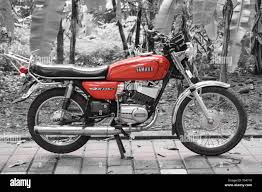

In [ ]:
#Open one of bike image
bike_img_pil=Image.open(bike_image_path)

bike_img_pil

In [ ]:
print("Bike Image mode:",bike_img_pil.mode)
print("Bike Image size:",bike_img_pil.size)

Bike Image mode: RGB
Bike Image size: (262, 192)


In [ ]:
#Extracting the image of car from folder
car_path=os.path.join(dataset_path,"Car")
car_filenames=os.listdir(car_path)
for image_name in os.listdir(car_path):
    car_image_path=os.path.join(car_path,image_name)
    img=cv2.imread(car_image_path)
    img=cv2.resize(img,(224,224))
    car_images.append(img)

print(len(car_images))

2000


In [ ]:
#For checking the path of any of car image
car_image_name=car_filenames[1]
print(car_image_name)
car_image_path=os.path.join(car_path,car_image_name)
print(car_image_path)

Car (1883).jpeg
/content/drive/MyDrive/Car-Bike-Dataset/Car/Car (1883).jpeg


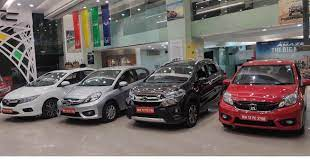

In [ ]:
#Open one of car image
car_img_pil=Image.open(car_image_path)
car_img_pil

In [ ]:
#Image mode+image-size
print("Bike Image:",car_img_pil.mode)
print("Bike Image size:",car_img_pil.size)

Bike Image: RGB
Bike Image size: (310, 162)


In [ ]:
#Establish a class to update the mode of image to "RGB"
class ConvertToRGB:
  def __call__(self,img):
        if img.mode!="RGB":
          img=img.convert("RGB")
        return img

In [ ]:
#Instantiate a transform pipeline
transform=transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
print(type(transform))
print(transform)

<class 'torchvision.transforms.transforms.Compose'>
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [ ]:
#load dataset using Image Folder
dataset=datasets.ImageFolder(root=dataset_path,transform=transform)

In [ ]:
#Find the no of classes and tensor shape of one image
print("Classes:")
print(dataset.classes)
print(f"That's {len(dataset.classes)} classes")
print()
print("Tensor shape for one image:")
print(dataset[0][0].shape)

Classes:
['Bike', 'Car']
That's 2 classes

Tensor shape for one image:
torch.Size([3, 224, 224])


In [ ]:
#0--->Bike 1---> car
im=dataset.imgs
print(im[0])
distinct_classes={x[1] for x in im}
print(distinct_classes)

('/content/drive/MyDrive/Car-Bike-Dataset/Bike/Bike (1).jpeg', 0)
{0, 1}


In [ ]:
g=torch.Generator()
g.manual_seed(42)
train_dataset,val_dataset,test_dataset=random_split(dataset,[0.8,0.1,0.1],generator=g)

In [ ]:
print(f"The length of training dataset:{len(train_dataset)}")
print(f"The length of val dataset:{len(val_dataset)}")
print(f"The length of test dataset:{len(test_dataset)}")

The length of training dataset:3200
The length of val dataset:400
The length of test dataset:400


In [ ]:
def class_counts(dataset):
  c=Counter(x[1] for x in tqdm(dataset))
  class_to_index=dataset.dataset.class_to_idx
  return pd.Series({cat:c[idx]for cat, idx in class_to_index.items()})

In [ ]:
train_counts=class_counts(train_dataset)

  0%|          | 0/3200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


<Axes: >

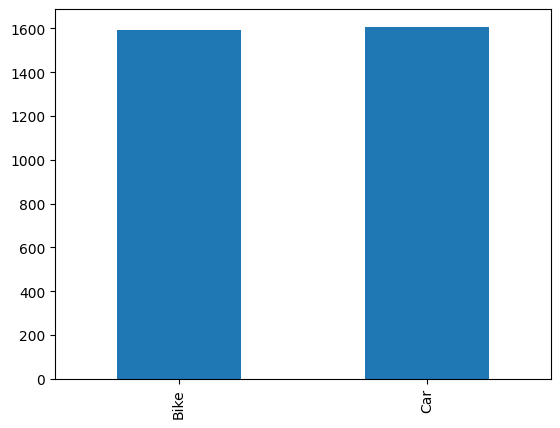

In [ ]:
train_counts.sort_values().plot(kind="bar")

In [ ]:
val_counts=class_counts(val_dataset)
print(val_counts)

  0%|          | 0/400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Bike    201
Car     199
dtype: int64


<Axes: >

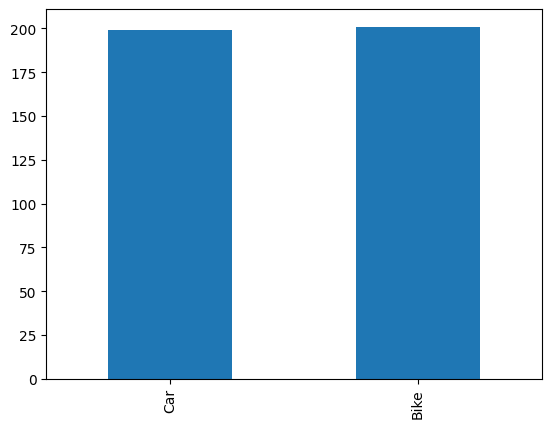

In [ ]:
val_counts.sort_values().plot(kind="bar")

In [ ]:
batch_size=32
dataset_loader=DataLoader(dataset,batch_size=batch_size)
print(type(dataset_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
g=torch.Generator()
g.manual_seed(42)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,generator=g)
print(type(train_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
print(type(dataset_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model=torch.nn.Sequential()
conv1=torch.nn.Conv2d(3,16,3,padding=1)
model.append(conv1)
maxpool1=torch.nn.MaxPool2d(2,2)
model.append(maxpool1)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [ ]:
conv2=torch.nn.Conv2d(16,32,3,padding=1)
model.append(conv2)
model.append(torch.nn.ReLU())
maxpool2=torch.nn.MaxPool2d(2,2)
model.append(maxpool2)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [ ]:
conv3=torch.nn.Conv2d(32,64,3,padding=1)
model.append(conv3)
model.append(torch.nn.ReLU())
maxpool3=torch.nn.MaxPool2d(2,2)
model.append(maxpool3)
model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())
linear1=torch.nn.Linear(in_features=50176,out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())
output_layer=torch.nn.Linear(500,2)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Dropout(p=0.5, inplace=False)
  (10): Linear(in_features=50176, out_features=500, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=500, out_features=2, bias=True)
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model=torch.nn.Sequential()
conv1=torch.nn.Conv2d(3,16,3,padding=1)
model.append(conv1)
model.append(torch.nn.ReLU())
maxpool1=torch.nn.MaxPool2d(2,2)
model.append(maxpool1)
conv2=torch.nn.Conv2d(16,32,3,padding=1)
model.append(conv2)
model.append(torch.nn.ReLU())
maxpool2=torch.nn.MaxPool2d(2,2)
model.append(maxpool2)
conv3=torch.nn.Conv2d(32,64,3,padding=1)
model.append(conv3)
model.append(torch.nn.ReLU())
maxpool3=torch.nn.MaxPool2d(2,2)
model.append(maxpool3)
model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())
linear1=torch.nn.Linear(in_features=50176,out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())
output_layer=torch.nn.Linear(500,2)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=2, bias=True)
)

In [ ]:
#looking at the summary
height,width=224,224
summary(model,input_size=(batch_size,3,height,width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 2]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

In [ ]:
#Setting up cross Entropy and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
def train_epoch(model,optimizer,loss_fn,data_loader,device="cpu"):
  training_losses=0.0
  model.train()#set the model to training mode
  for inputs, targets in tqdm(data_loader,desc="Training",leave=False):
    optimizer.zero_grad()
    ''' In pytorch gradients accumulate by default so it clears the previous gradient
        so for before each backward pass reset them or else gradients from previous batch will be added '''
    inputs=inputs.to(device)
    targets=targets.to(device)
    ''' Forward pass Model predicts output for current batch '''
    output=model(inputs)
    ''' Compute loss func. between predicted output and true labels '''
    loss=loss_fn(output,targets)
    loss.backward()
    ''' Updates weights using gradients'''
    optimizer.step()
    training_losses+=loss.data.item()*inputs.size(0)
    ''' Divide total loss by total sample '''
  return training_losses/len(data_loader.dataset)


In [ ]:
loss_value=train_epoch(model,optimizer,loss_fn,train_loader,device)
print(f"The average loss during the training epoch was {loss_value:.2f}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


The average loss during the training epoch was 0.62


In [88]:
def predict(model, data_loader, device="cpu"):

    model.eval()
    all_probs = []   # Use list instead of empty tensor

    with torch.no_grad():
        for inputs, targets in tqdm(data_loader, desc="Predicting", leave=False):

            inputs = inputs.to(device)
            '''Output generally have a shape like (batchsize,num_classes) so the tensor look like somewhat around [2.3,5.6,....2.1]
               we use dim=1 because we want probabilities across classes so softmax convert the tensor
               values into probabilitis that sum upto one'''
            outputs = model(inputs)

            probs = F.softmax(outputs, dim=1) #Here dim=1 means classes of outputs and dim=0 means batch_size

            all_probs.append(probs)   # Just append.
            '''Each row is one sample Each column is the probability of one class
              so suppose classes=10 batch size=32
              then it looks somewhat like
              [p1,p2,p3,....p10] <-- sample1
                 32 rows
              [p1,p2,p3,....p10] <-- sample 32 '''

    return torch.cat(all_probs, dim=0)  # Concatenate once

In [86]:
eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

In [89]:
probabilities_train=predict(model,eval_loader,device)
probabilities_train.shape

Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


torch.Size([3200, 2])

In [90]:
len(eval_loader.dataset)

3200

In [91]:
probabilities_val=predict(model,val_loader,device)
probabilities_val.shape

Predicting:   0%|          | 0/13 [00:00<?, ?it/s]

torch.Size([400, 2])

In [92]:
print(probabilities_train[0])

tensor([0.9878, 0.0122])


In [93]:
print(probabilities_val[0])
print(probabilities_val[0].sum())

tensor([0.0304, 0.9696])
tensor(1.)


In [94]:
'''argmax returns the index of max value along a given dimension '''
prediction_train=torch.argmax(probabilities_train,dim=1)
print(prediction_train)
print(f"Predictions Shape:{prediction_train.shape}")
print(f"First 10 predictions:{prediction_train[:10]}")

tensor([0, 1, 0,  ..., 1, 1, 1])
Predictions Shape:torch.Size([3200])
First 10 predictions:tensor([0, 1, 0, 0, 1, 1, 0, 0, 0, 1])


In [95]:
prediction_val=torch.argmax(probabilities_val,dim=1)

print(f"Predictions Shape:{prediction_val.shape}")
print(f"First 10 predictions:{prediction_val[:10]}")

Predictions Shape:torch.Size([400])
First 10 predictions:tensor([1, 1, 1, 1, 1, 0, 1, 1, 0, 0])


In [96]:
target_train=torch.cat([labels for _, labels in eval_loader]).to(device)
is_correct_train=torch.eq(prediction_train,target_train)
total_correct_train=torch.sum(is_correct_train).item()
acc_train=total_correct_train/len(train_loader.dataset)
print(f"Accurcy for train data:{acc_train}")

Accurcy for train data:0.8696875


In [97]:
target_val=torch.cat([labels for _, labels in val_loader]).to(device)
is_correct_train=torch.eq(prediction_val,target_val)
total_correct_val=torch.sum(is_correct_train).item()
acc_val=total_correct_val/len(val_loader.dataset)
print(f"Accurcy for train data:{acc_val}")

Accurcy for train data:0.855


In [98]:
def score(predictions, data_loader, device="cpu"):
    # collect labels in correct order
    targets = torch.cat([labels for _, labels in data_loader]).to(device)

    # compare
    correct = (predictions == targets).sum().item()

    # compute accuracy
    accuracy = correct / len(data_loader.dataset)

    return accuracy

In [99]:
acc_train = score(prediction_train, eval_loader, device)
print(f"Accuracy for train data: {acc_train}")

acc_val = score(prediction_val, val_loader, device)
print(f"Accuracy for val data: {acc_val}")

Accuracy for train data: 0.8696875
Accuracy for val data: 0.855


In [104]:
def train(model,optimizer,loss_fn,train_loader,val_loader,epochs=20,device="cpu"):
  for epoch in range(1,epochs+1):
    training_loss=train_epoch(model,optimizer,loss_fn,train_loader,device="cpu")
    val_acc= score(prediction_val, val_loader, device)
    print(f"Epoch:{epoch},Training_loss:{training_loss:.2f},Val_acc:{val_acc:.2f}")



In [105]:
train(model,optimizer,loss_fn,train_loader,val_loader,epochs=5,device="cpu")

Training:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch:1,Training_loss:0.13,Val_acc:0.85


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch:2,Training_loss:0.11,Val_acc:0.85


...

Epoch:3,Training_loss:0.08,Val_acc:0.85


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch:4,Training_loss:0.06,Val_acc:0.85


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch:5,Training_loss:0.05,Val_acc:0.85


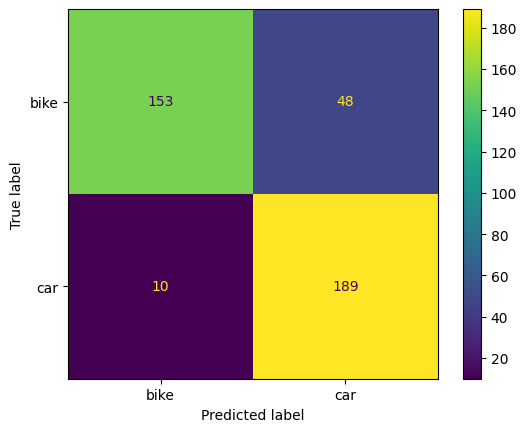

In [109]:
cm=confusion_matrix(target_val.cpu(),prediction_val.cpu())
disp=ConfusionMatrixDisplay( confusion_matrix=cm,display_labels=["bike","car"])
disp.plot()

The model predicted

 153 --> correctly predicte as bike

 48 --> bike predicted as car

 10 --> car predicted as bike

 189 --> car predicted as car

So the model correctly predicts car most of time
but for bike the model is little bit weaker

In [115]:
from sklearn.metrics import precision_score,f1_score,recall_score
Precision_score=precision_score(target_val.cpu(),prediction_val.cpu())
print("Precision score:",Precision_score)
f1=f1_score(target_val.cpu(),prediction_val.cpu())
print("F1 Score:",f1)
recall=recall_score(target_val.cpu(),prediction_val.cpu())
print("Recall Score:",recall)

Precision score: 0.7974683544303798
F1 Score: 0.8669724770642202
Recall Score: 0.949748743718593
